# Evaluation and Analysis

In [ ]:
!unzip "/content/airfoil_surrogate-20260428T054106Z-3-001.zip" -d "/content/airfoil_data"

Archive:  /content/airfoil_surrogate-20260428T054106Z-3-001.zip
  inflating: /content/airfoil_data/airfoil_surrogate/names_test.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/X_val.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/dataset_stats.json  
  inflating: /content/airfoil_data/airfoil_surrogate/names_train.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/y_val.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/airfoil_dataset_labeled.pkl  
  inflating: /content/airfoil_data/airfoil_surrogate/xfoil_checkpoint.pkl  
  inflating: /content/airfoil_data/airfoil_surrogate/y_train.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/X_test.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/airfoil_dataset_raw.pkl  
  inflating: /content/airfoil_data/airfoil_surrogate/airfoil_dataset_final.pkl  
  inflating: /content/airfoil_data/airfoil_surrogate/X_train.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/names_val.npy  
  i

In [ ]:
!unzip "/content/model_outputs.zip" -d "/content/model_outputs"

Archive:  /content/model_outputs.zip
  inflating: /content/model_outputs/envelope_filtering.png  
  inflating: /content/model_outputs/cnn1d_attention_best.pt  
  inflating: /content/model_outputs/envelope.json  
  inflating: /content/model_outputs/cnn1d_best.pt  
  inflating: /content/model_outputs/scalers.pkl  
  inflating: /content/model_outputs/training_histories.pkl  
  inflating: /content/model_outputs/mlp_baseline_best.pt  
  inflating: /content/model_outputs/X_test_ood.npy  
  inflating: /content/model_outputs/y_test_ood.npy  
  inflating: /content/model_outputs/training_curves.png  


In [ ]:
!pip install -q torch matplotlib numpy pandas scikit-learn seaborn

In [ ]:
import json
import pickle as pkl
import shutil
import subprocess
import tempfile
import time
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import r2_score
from torch.utils.data import Dataset, DataLoader

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

_DRIVE_DIR= Path('/content/drive/My Drive/airfoil_surrogate')
_DRIVE_MODEL = _DRIVE_DIR / 'models'
_COORD_DIR = _DRIVE_DIR / 'coordinates'
_XFOIL_COORD = Path('/content/xfoil_coords')
_OUTPUT_DIR = Path('/content/eval_outputs')
_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _p(filename: str, model: bool = False) -> Path:
    return (_DRIVE_MODEL if model else _DRIVE_DIR) / filename
'''
print(f'Data dir  : {_DRIVE_DIR}')
print(f'Model dir : {_DRIVE_MODEL}')
print(f'Eval out  : {_OUTPUT_DIR}')
'''

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

X_test_raw = np.load(_p('X_test.npy'))
y_test_raw = np.load(_p('y_test.npy'))
X_geom_test_raw = np.load(_p('X_geom_test.npy'))

df_full = pd.read_pickle(_p('airfoil_dataset_final.pkl'))
df_test_full = df_full[df_full['split'] == 'test'].reset_index(drop=True)

with open(_p('dataset_stats.json')) as f:
    _stats = json.load(f)
N_POINTS= _stats['n_resample_points']  # 200
INPUT_DIM = _stats['input_dim'] #402
GEOM_DIM = _stats.get('geom_input_dim', 209)
N_GRID = 100

with open(_p('scalers.pkl', model=True), 'rb') as f:
    _scalers = pkl.load(f)
X_scaler = _scalers['X_scaler']
Xg_scaler= _scalers['Xg_scaler']
y_scaler = _scalers['y_scaler']

with open(_p('envelope.json', model=True)) as f:
    ENVELOPE = json.load(f)

print('Loaded successfully.')
print(f'Test raw shape:  {X_test_raw.shape}')
print(f'Test geom shape: {X_geom_test_raw.shape}')
print('Envelope:', ENVELOPE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded successfully.
Test raw shape:  (1381, 402)
Test geom shape: (1381, 207)
Envelope: {'aoa_min': -2.0, 'aoa_max': 10.0, 'CL_min': -0.5, 'CL_max': 3.0, 'CD_min': 0.001, 'CD_max': 0.06, 'reynolds_min': 500000, 'reynolds_max': 2000000}


In [ ]:
mask_test = (
    (df_test_full['aoa'] >= ENVELOPE['aoa_min']) &
    (df_test_full['aoa'] <= ENVELOPE['aoa_max']) &
    (df_test_full['CL'] >= ENVELOPE['CL_min'])  &
    (df_test_full['CL'] <= ENVELOPE['CL_max'])  &
    (df_test_full['CD'] >= ENVELOPE['CD_min'])  &
    (df_test_full['CD'] <= ENVELOPE['CD_max'])
).values

X_test_id_s= X_scaler.transform(X_test_raw[mask_test]).astype(np.float32)
Xg_test_id_s = Xg_scaler.transform(X_geom_test_raw[mask_test]).astype(np.float32)
y_test_id = y_test_raw[mask_test]
df_test_id = df_test_full[mask_test].reset_index(drop=True)

X_test_ood_s = X_scaler.transform(X_test_raw[~mask_test]).astype(np.float32)
Xg_test_ood_s = Xg_scaler.transform(X_geom_test_raw[~mask_test]).astype(np.float32)
y_test_ood = y_test_raw[~mask_test]
df_test_ood = df_test_full[~mask_test].reset_index(drop=True)

print(f'In-distribution test samples : {len(X_test_id_s)}')
print(f'OOD test samples             : {len(X_test_ood_s)}')
print(f'OOD fraction                 : {len(X_test_ood_s)/len(X_test_raw)*100:.1f}%')


In-distribution test samples : 926
OOD test samples             : 455
OOD fraction                 : 32.9%


In [ ]:
class ResidualBlock1D(nn.Module):
    def __init__(self, channels, kernel_size=5, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel_size - 1) * dilation // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad, dilation=dilation),
            nn.BatchNorm1d(channels), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=pad, dilation=dilation),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.GELU()
    def forward(self, x): return self.act(x + self.block(x))

class MLPBaseline(nn.Module):
    def __init__(self, input_dim=402, hidden_dims=None, dropout=0.2):
        super().__init__()
        if hidden_dims is None: hidden_dims = [512, 512, 256, 128]
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 2))
        self.net = nn.Sequential(*layers)
    def forward(self, x, _s=None): return self.net(x)


class ImprovedCNN1D(nn.Module):
    def __init__(self, n_grid=100, base_channels=64, n_res_blocks=3,scalar_dim=7, dropout=0.10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(2, base_channels, 7, padding=3),
            nn.BatchNorm1d(base_channels), nn.GELU())
        blocks, ch = [], base_channels
        dilations = [1, 2, 4]
        for i in range(n_res_blocks):
            d = dilations[i % len(dilations)]
            blocks.append(ResidualBlock1D(ch, 5, dilation=d, dropout=dropout))
            if i < n_res_blocks - 1:
                oc = ch * 2
                blocks.append(nn.Sequential(
                    nn.Conv1d(ch, oc, 3, stride=2, padding=1),
                    nn.BatchNorm1d(oc), nn.GELU()))
                ch = oc
        self.encoder = nn.Sequential(*blocks)
        self.gap= nn.AdaptiveAvgPool1d(1)
        self.film_net = nn.Sequential(nn.Linear(2, 64), nn.GELU(), nn.Linear(64, 2*ch))
        self.scalar_branch = nn.Sequential(nn.Linear(scalar_dim, 64), nn.GELU(), nn.Linear(64, 64), nn.GELU())
        self.head = nn.Sequential(nn.Linear(ch + 64, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128, 64), nn.GELU(), nn.Linear(64, 2))
    def forward(self, seq, scalar):
        x = self.gap(self.encoder(self.stem(seq))).squeeze(-1)
        gamma, beta = self.film_net(scalar[:, -2:]).chunk(2, dim=-1)
        return self.head(torch.cat([gamma*x+beta, self.scalar_branch(scalar)], dim=-1))


class ImprovedCNN1DAttn(nn.Module):
    def __init__(self, n_grid=100, base_channels=64, n_res_blocks=3, scalar_dim=7, n_heads=4, dropout=0.10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(2, base_channels, 7, padding=3), nn.BatchNorm1d(base_channels), nn.GELU())
        blocks, ch = [], base_channels
        dilations = [1, 2, 4]
        for i in range(n_res_blocks):
            d = dilations[i % len(dilations)]
            blocks.append(ResidualBlock1D(ch, 5, dilation=d, dropout=dropout))
            if i < n_res_blocks - 1:
                oc = ch * 2
                blocks.append(nn.Sequential(
                    nn.Conv1d(ch, oc, 3, stride=2, padding=1), nn.BatchNorm1d(oc), nn.GELU()))
                ch = oc
        self.encoder= nn.Sequential(*blocks)
        self.attn_norm = nn.LayerNorm(ch)
        self.attn= nn.MultiheadAttention(ch, n_heads, dropout=dropout, batch_first=True)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.film_net = nn.Sequential(nn.Linear(2, 64), nn.GELU(), nn.Linear(64, 2*ch))
        self.scalar_branch = nn.Sequential(nn.Linear(scalar_dim, 64), nn.GELU(), nn.Linear(64, 64), nn.GELU())
        self.head = nn.Sequential(nn.Linear(ch + 64, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128, 64), nn.GELU(), nn.Linear(64, 2))
    def forward(self, seq, scalar):
        x = self.encoder(self.stem(seq))
        x_t = self.attn_norm(x.permute(0, 2, 1))
        x_t, _ = self.attn(x_t, x_t, x_t)
        x = self.gap(x + x_t.permute(0, 2, 1)).squeeze(-1)
        gamma, beta = self.film_net(scalar[:, -2:]).chunk(2, dim=-1)
        return self.head(torch.cat([gamma*x+beta, self.scalar_branch(scalar)], dim=-1))


SCALAR_DIM = GEOM_DIM - 2 * N_GRID   # = 7

mlp = MLPBaseline(INPUT_DIM).to(DEVICE)
cnn = ImprovedCNN1D(N_GRID, scalar_dim=SCALAR_DIM).to(DEVICE)
cnn_attn = ImprovedCNN1DAttn(N_GRID, scalar_dim=SCALAR_DIM).to(DEVICE)

mlp.load_state_dict(torch.load(_p('mlp_baseline_best.pt', model=True), map_location=DEVICE))
cnn.load_state_dict(torch.load(_p('cnn1d_best.pt', model=True), map_location=DEVICE))
cnn_attn.load_state_dict(torch.load(_p('cnn1d_attention_best.pt', model=True), map_location=DEVICE))

for m in [mlp, cnn, cnn_attn]: m.eval()
print('All models loaded.')
print(f'MLP params:      {sum(p.numel() for p in mlp.parameters()):,}')
print(f'CNN params:      {sum(p.numel() for p in cnn.parameters()):,}')
print(f'CNN+Attn params: {sum(p.numel() for p in cnn_attn.parameters()):,}')


All models loaded.
MLP params:      636,290
CNN params:      1,075,842
CNN+Attn params: 1,339,522


In [ ]:
class GeomAirfoilDataset(Dataset):
    #Geom features for CNN inference
    def __init__(self, X_geom_norm, y_raw, n_grid=100):
        self.X = torch.from_numpy(X_geom_norm)
        self.y = torch.from_numpy(y_scaler.transform(y_raw).astype(np.float32))
        self.ng = n_grid
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = self.X[i]
        return x[:2*self.ng].reshape(2, self.ng), x[2*self.ng:], self.y[i]


@torch.no_grad()
def get_preds_raw(model, X_norm, y_raw, device=DEVICE, batch_size=1024):
    #MLP predictions (flat input)
    ds= torch.utils.data.TensorDataset(torch.from_numpy(X_norm))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds = []
    model.eval()
    for (x,) in loader:
        preds.append(model(x.to(device)).cpu())
    return y_scaler.inverse_transform(torch.cat(preds).numpy()), y_raw


@torch.no_grad()
def get_preds_geom(model, X_geom_norm, y_raw, device=DEVICE, batch_size=1024, n_grid=100):
    #CNN predictions (geom input)
    ds = GeomAirfoilDataset(X_geom_norm, y_raw, n_grid)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds = []
    model.eval()
    for g, s, _ in loader:
        preds.append(model(g.to(device), s.to(device)).cpu())
    return y_scaler.inverse_transform(torch.cat(preds).numpy()), y_raw

preds_mlp_id, tgt_id = get_preds_raw( mlp, X_test_id_s, y_test_id)
preds_cnn_id, _ = get_preds_geom(cnn, Xg_test_id_s, y_test_id)
preds_attn_id, _ = get_preds_geom(cnn_attn, Xg_test_id_s, y_test_id)
preds_ens_id= (preds_cnn_id + preds_attn_id) / 2.0

preds_mlp_ood,tgt_ood = get_preds_raw( mlp, X_test_ood_s, y_test_ood)
preds_cnn_ood, _ = get_preds_geom(cnn,Xg_test_ood_s,y_test_ood)
preds_attn_ood, _ = get_preds_geom(cnn_attn, Xg_test_ood_s, y_test_ood)

X_all_s = X_scaler.transform(X_test_raw).astype(np.float32)
Xg_all_s = Xg_scaler.transform(X_geom_test_raw).astype(np.float32)
preds_cnn_all, tgt_all = get_preds_geom(cnn, Xg_all_s, y_test_raw)

print(f'ID   predictions: {preds_cnn_id.shape}')
print(f'OOD  predictions: {preds_cnn_ood.shape}')
print(f'All  predictions: {preds_cnn_all.shape}')
print(f'Ensemble available: preds_ens_id')


ID   predictions: (926, 2)
OOD  predictions: (455, 2)
All  predictions: (1381, 2)
Ensemble available: preds_ens_id


In [ ]:
def compute_metrics(preds, targets, label=''):
    """Computes RMSE, MAE, filtered MAPE (|CL|>0.1 only), R^2

    MAPE is excluded for near-zero CL samples to avoid division-by-zero artifacts that result in meaninglessly large percentages.
    """
    rows = []
    for i, c in enumerate(['CL', 'CD']):
        p, t = preds[:, i], targets[:, i]
        # MAPE: only where |target| > threshold
        if c == 'CL':
            mape_mask = np.abs(t) > 0.1
        else:
            mape_mask = np.abs(t) > 0.001
        mape = float(np.mean(np.abs((p[mape_mask]-t[mape_mask])/np.abs(t[mape_mask])))*100)
        if mape_mask.sum() > 0 else float('nan')
        rows.append({
            'Coeff': c,
            'RMSE': float(np.sqrt(np.mean((p-t)**2))),
            'MAE': float(np.mean(np.abs(p-t))),
            'MAPE%': mape,
            'R2': float(r2_score(t, p)),
        })
    df = pd.DataFrame(rows)
    if label:
        print(f'\n{label}')
        print(df.to_string(index=False, float_format='{:.4f}'.format))
    return df


print('=' * 60)
print('IN-DISTRIBUTION TEST SET METRICS')
print('=' * 60)
m_mlp = compute_metrics(preds_mlp_id, tgt_id,'MLP Baseline')
m_cnn = compute_metrics(preds_cnn_id, tgt_id, 'Improved 1D CNN')
m_attn = compute_metrics(preds_attn_id, tgt_id, '1D CNN + Attention')
m_ens = compute_metrics(preds_ens_id, tgt_id, 'Ensemble (CNN + CNN+Attn)')


IN-DISTRIBUTION TEST SET METRICS

MLP Baseline
Coeff   RMSE    MAE   MAPE%     R2
   CL 0.1493 0.0845 13.9719 0.9341
   CD 0.0017 0.0012 20.5970 0.7401

Improved 1D CNN
Coeff   RMSE    MAE   MAPE%     R2
   CL 0.1143 0.0590  8.8097 0.9613
   CD 0.0017 0.0011 21.0277 0.7473

1D CNN + Attention
Coeff   RMSE    MAE   MAPE%     R2
   CL 0.1049 0.0576  8.5481 0.9675
   CD 0.0018 0.0012 22.3754 0.7196

Ensemble (CNN + CNN+Attn)
Coeff   RMSE    MAE   MAPE%     R2
   CL 0.1064 0.0551  8.1222 0.9665
   CD 0.0017 0.0011 21.3077 0.7417


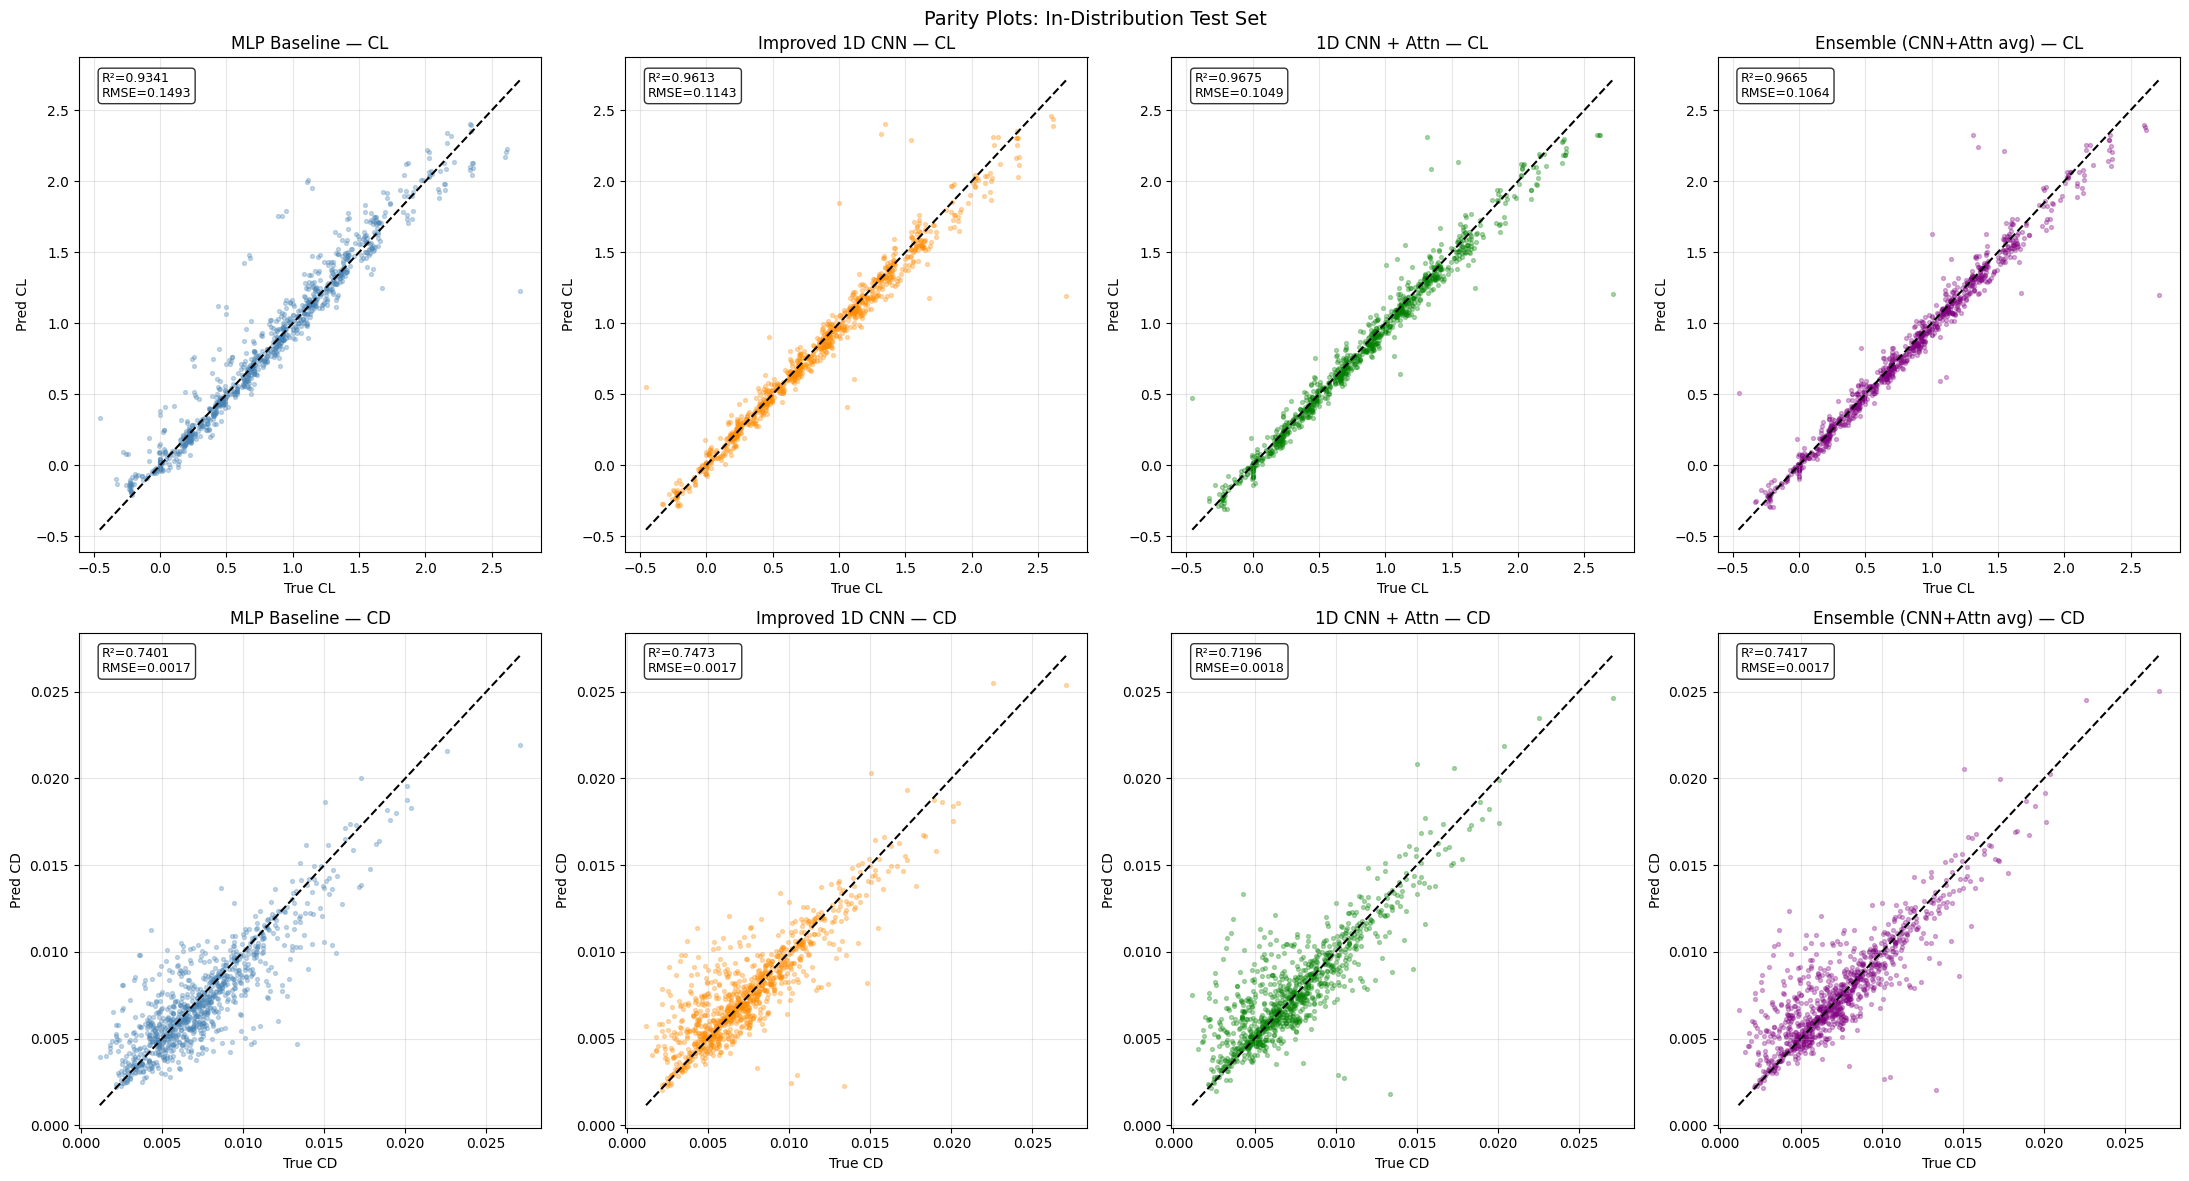

Saved parity_plots.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
for col, (name, preds, color) in enumerate([
    ('MLP Baseline', preds_mlp_id, 'steelblue'),
    ('Improved 1D CNN', preds_cnn_id, 'darkorange'),
    ('1D CNN + Attn', preds_attn_id, 'green'),
    ('Ensemble (CNN+Attn avg)', preds_ens_id, 'purple'),
]):
    for row, (ci, cn) in enumerate([(0, 'CL'), (1, 'CD')]):
        ax = axes[row, col]
        t, p = tgt_id[:, ci], preds[:, ci]
        idx = np.random.choice(len(t), min(2000, len(t)), replace=False)
        ax.scatter(t[idx], p[idx], alpha=0.3, s=8, color=color)
        lim = [min(t.min(), p.min()), max(t.max(), p.max())]
        ax.plot(lim, lim, 'k--', lw=1.5)
        r2 = r2_score(t, p)
        rmse = np.sqrt(np.mean((p-t)**2))
        ax.text(0.05, 0.92, f'R²={r2:.4f}\nRMSE={rmse:.4f}',transform=ax.transAxes, fontsize=9,bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_xlabel(f'True {cn}'); ax.set_ylabel(f'Pred {cn}')
        ax.set_title(f'{name} — {cn}'); ax.grid(alpha=0.3)
plt.suptitle('Parity Plots: In-Distribution Test Set', fontsize=14)
plt.tight_layout()
plt.savefig(_OUTPUT_DIR / 'parity_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved parity_plots.png')


In [ ]:
print('=' * 60)
print('OOD DEGRADATION ANALYSIS')
print('=' * 60)
m_mlp_ood  = compute_metrics(preds_mlp_ood,  tgt_ood, 'MLP Baseline — OOD')
m_cnn_ood  = compute_metrics(preds_cnn_ood,  tgt_ood, 'Improved CNN — OOD')

print('\nDegradation summary (ID RMSE → OOD RMSE):')
for name, m_id, m_ood in [('MLP', m_mlp, m_mlp_ood), ('CNN', m_cnn, m_cnn_ood)]:
    for cn in ['CL', 'CD']:
        id_r  = m_id[m_id['Coeff']==cn]['RMSE'].values[0]
        ood_r = m_ood[m_ood['Coeff']==cn]['RMSE'].values[0]
        print(f'  {name} {cn}: {id_r:.4f} → {ood_r:.4f}  [{ood_r/id_r:.1f}× worse]')


OOD DEGRADATION ANALYSIS

MLP Baseline — OOD
Coeff   RMSE    MAE   MAPE%     R2
   CL 0.6106 0.3429 24.7171 0.7806
   CD 0.0034 0.0025 33.1173 0.6212

Improved CNN — OOD
Coeff   RMSE    MAE   MAPE%     R2
   CL 0.6904 0.4377 27.8611 0.7195
   CD 0.0036 0.0025 33.7888 0.5904

Degradation summary (ID RMSE → OOD RMSE):
  MLP CL: 0.1493 → 0.6106  [4.1× worse]
  MLP CD: 0.0017 → 0.0034  [2.0× worse]
  CNN CL: 0.1143 → 0.6904  [6.0× worse]
  CNN CD: 0.0017 → 0.0036  [2.1× worse]


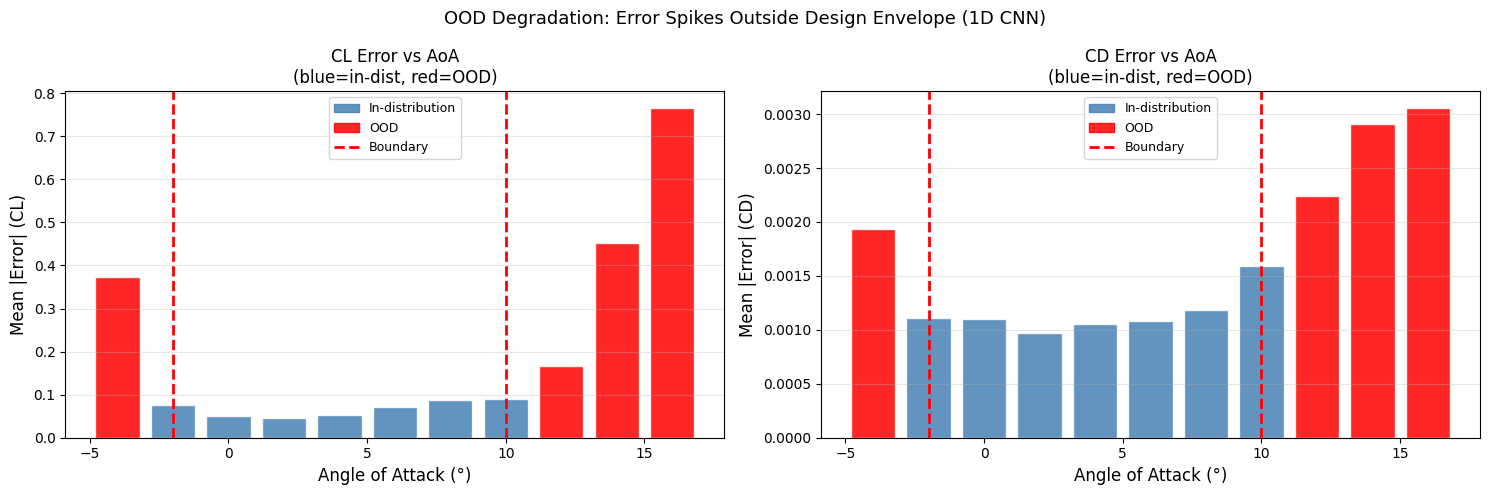

Saved ood_degradation_by_aoa.png


In [ ]:
# Error per AoA bin across the full test set (ID + OOD)
df_all = df_test_full.copy().reset_index(drop=True)
df_all['CL_AE'] = np.abs(preds_cnn_all[:, 0] - tgt_all[:, 0])
df_all['CD_AE'] = np.abs(preds_cnn_all[:, 1] - tgt_all[:, 1])
df_all['in_dist'] = mask_test

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, coeff in zip(axes, ['CL_AE', 'CD_AE']):
    aoa_vals = sorted(df_all['aoa'].unique())
    means = [df_all[df_all['aoa'] == a][coeff].mean() for a in aoa_vals]
    colors = ['steelblue' if ENVELOPE['aoa_min'] <= a <= ENVELOPE['aoa_max']
                else 'red' for a in aoa_vals]
    ax.bar(aoa_vals, means, color=colors, alpha=0.85, width=1.6, edgecolor='white')
    ax.axvline(ENVELOPE['aoa_min'], color='red', ls='--', lw=2)
    ax.axvline(ENVELOPE['aoa_max'], color='red', ls='--', lw=2,
               label=f'Envelope [{ENVELOPE["aoa_min"]}°, {ENVELOPE["aoa_max"]}°]')
    id_patch= mpatches.Patch(color='steelblue', alpha=0.85, label='In-distribution')
    ood_patch = mpatches.Patch(color='red',       alpha=0.85, label='OOD')
    bnd_line= plt.Line2D([0],[0], color='red', ls='--', lw=2, label='Boundary')
    ax.legend(handles=[id_patch, ood_patch, bnd_line], fontsize=9)
    ax.set_xlabel('Angle of Attack (°)', fontsize=12)
    ax.set_ylabel(f'Mean |Error| ({coeff.replace("_AE","")})', fontsize=12)
    ax.set_title(f'{coeff.replace("_AE","")} Error vs AoA\n(blue=in-dist, red=OOD)',fontsize=12)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('OOD Degradation: Error Spikes Outside Design Envelope (1D CNN)', fontsize=13)
plt.tight_layout()
plt.savefig(_OUTPUT_DIR / 'ood_degradation_by_aoa.png', dpi=150)
plt.show()
print('Saved ood_degradation_by_aoa.png')

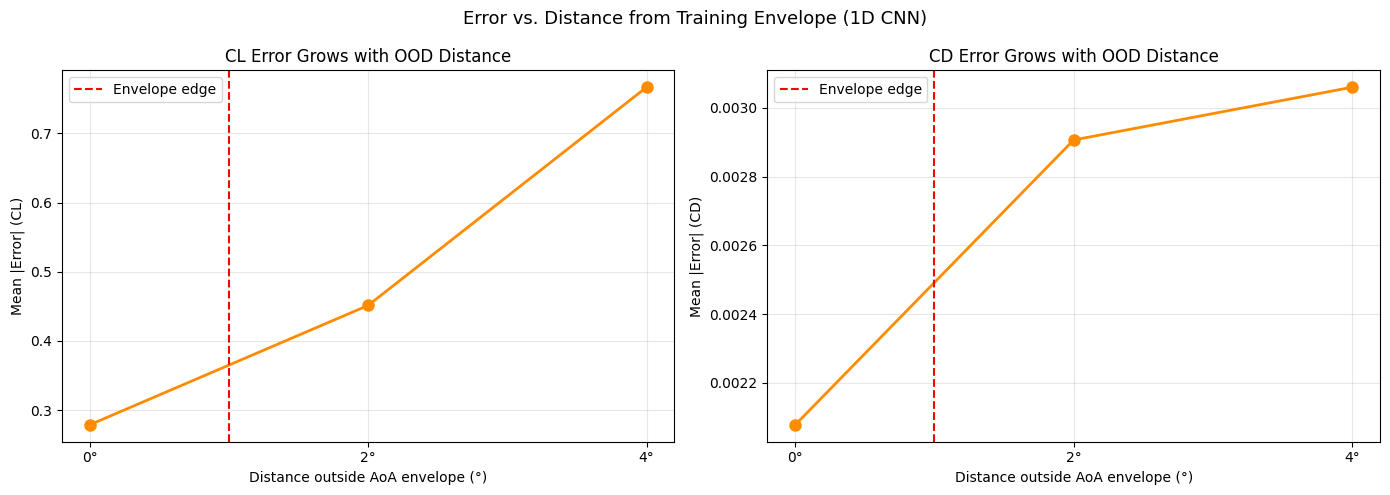

Saved ood_error_vs_distance.png


In [ ]:
# Error vs. distance from envelope boundary
df_all['aoa_dist'] = df_all['aoa'].apply(lambda a: max(ENVELOPE['aoa_min'] - a, 0.0, a - ENVELOPE['aoa_max']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, coeff in zip(axes, ['CL_AE', 'CD_AE']):
    bins = np.arange(0, df_all['aoa_dist'].max() + 2, 2)
    df_all['dist_bin'] = pd.cut(df_all['aoa_dist'], bins=bins, labels=[f'{b:.0f}' for b in bins[:-1]])
    grp = df_all.groupby('dist_bin', observed=True)[coeff].mean()
    ax.plot(range(len(grp)), grp.values, 'o-', color='darkorange', lw=2, ms=8)
    ax.axvline(0.5, color='red', ls='--', lw=1.5, label='Envelope edge')
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels([f'{b:.0f}°' for b in bins[:-1]])
    ax.set_xlabel('Distance outside AoA envelope (°)')
    ax.set_ylabel(f'Mean |Error| ({coeff.replace("_AE","")})')
    ax.set_title(f'{coeff.replace("_AE","")} Error Grows with OOD Distance')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Error vs. Distance from Training Envelope (1D CNN)', fontsize=13)
plt.tight_layout()
plt.savefig(_OUTPUT_DIR / 'ood_error_vs_distance.png', dpi=150)
plt.show()
print('Saved ood_error_vs_distance.png')

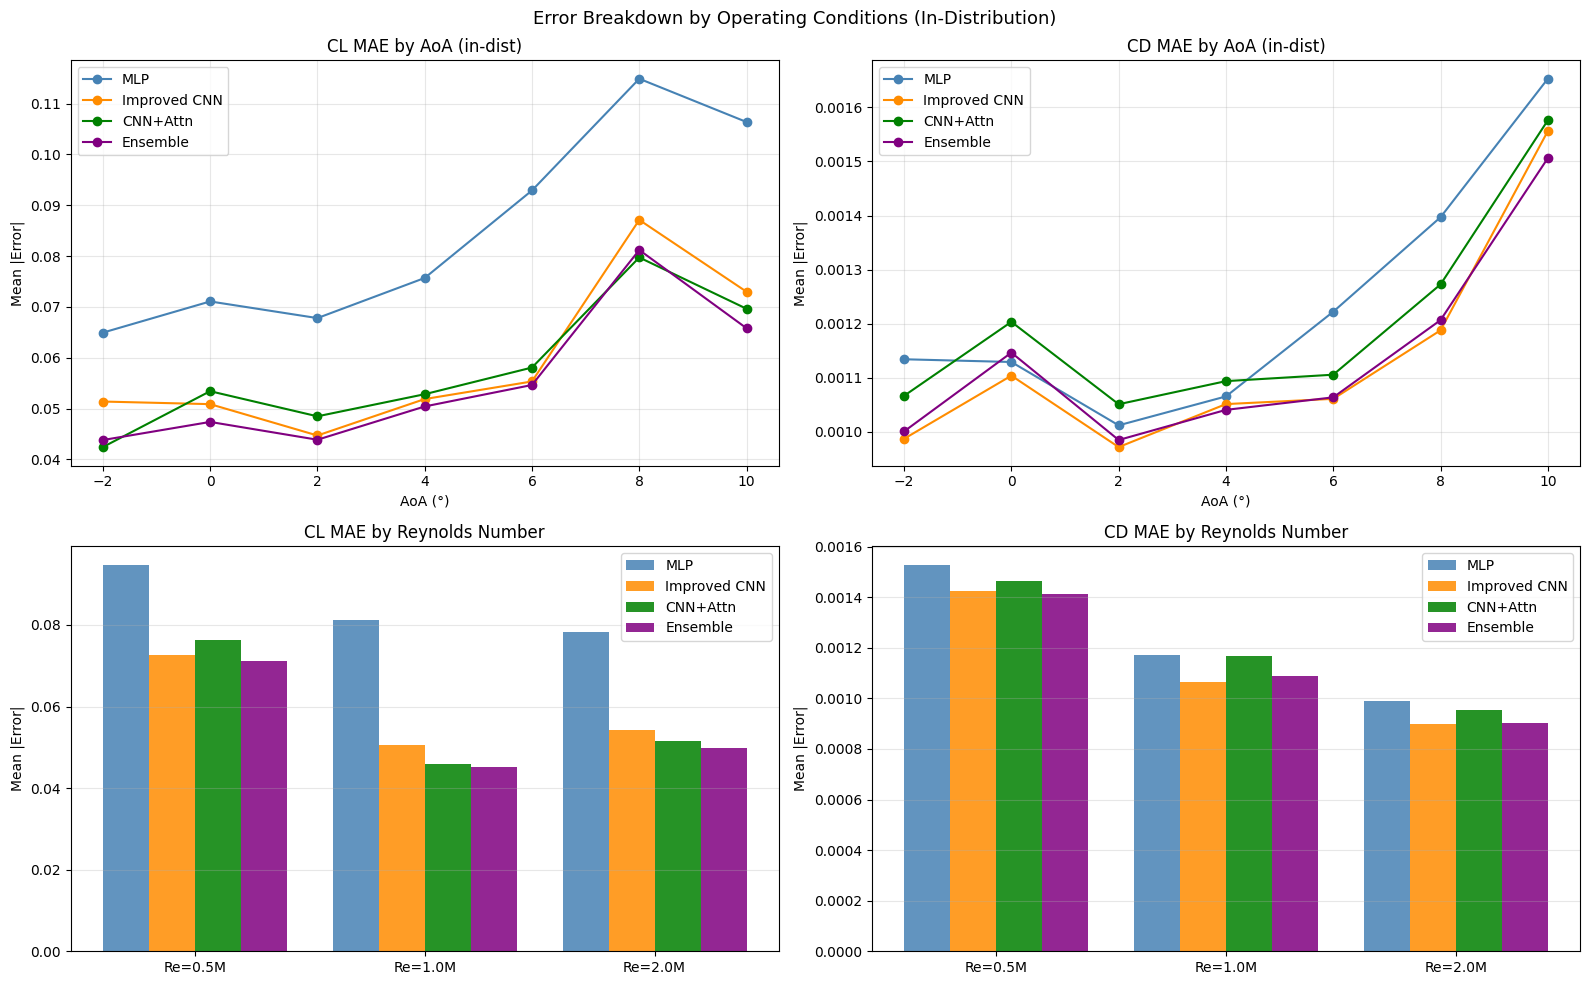

Saved error_breakdown.png


In [ ]:
df_eval = df_test_id.copy()
for tag, pred in [
    ('mlp',  preds_mlp_id),
    ('cnn',  preds_cnn_id),
    ('attn', preds_attn_id),
    ('ens', preds_ens_id),
]:
    df_eval[f'CL_AE_{tag}'] = np.abs(pred[:, 0] - tgt_id[:, 0])
    df_eval[f'CD_AE_{tag}'] = np.abs(pred[:, 1] - tgt_id[:, 1])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
mplot = [
    ('mlp',  'MLP','steelblue'),
    ('cnn',  'Improved CNN', 'darkorange'),
    ('attn', 'CNN+Attn', 'green'),
    ('ens',  'Ensemble', 'purple'),
]

for ax, coeff in zip(axes[0], ['CL_AE', 'CD_AE']):
    for tag, label, color in mplot:
        grp = df_eval.groupby('aoa')[f'{coeff}_{tag}'].mean()
        ax.plot(grp.index, grp.values, 'o-', label=label, color=color)
    ax.set_xlabel('AoA (°)'); ax.set_ylabel('Mean |Error|')
    ax.set_title(f'{coeff.replace("_AE","")} MAE by AoA (in-dist)')
    ax.legend(); ax.grid(alpha=0.3)

re_vals = sorted(df_eval['reynolds'].unique())
x_pos, w = np.arange(len(re_vals)), 0.20
for ax, coeff in zip(axes[1], ['CL_AE', 'CD_AE']):
    for j, (tag, label, color) in enumerate(mplot):
        means = [df_eval[df_eval['reynolds']==re][f'{coeff}_{tag}'].mean() for re in re_vals]
        ax.bar(x_pos + j*w, means, w, label=label, color=color, alpha=0.85)
    ax.set_xticks(x_pos + 1.5*w)
    ax.set_xticklabels([f'Re={r/1e6:.1f}M' for r in re_vals])
    ax.set_ylabel('Mean |Error|')
    ax.set_title(f'{coeff.replace("_AE","")} MAE by Reynolds Number')
    ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.suptitle('Error Breakdown by Operating Conditions (In-Distribution)', fontsize=13)
plt.tight_layout()
plt.savefig(_OUTPUT_DIR / 'error_breakdown.png', dpi=150)
plt.show()
print('Saved error_breakdown.png')


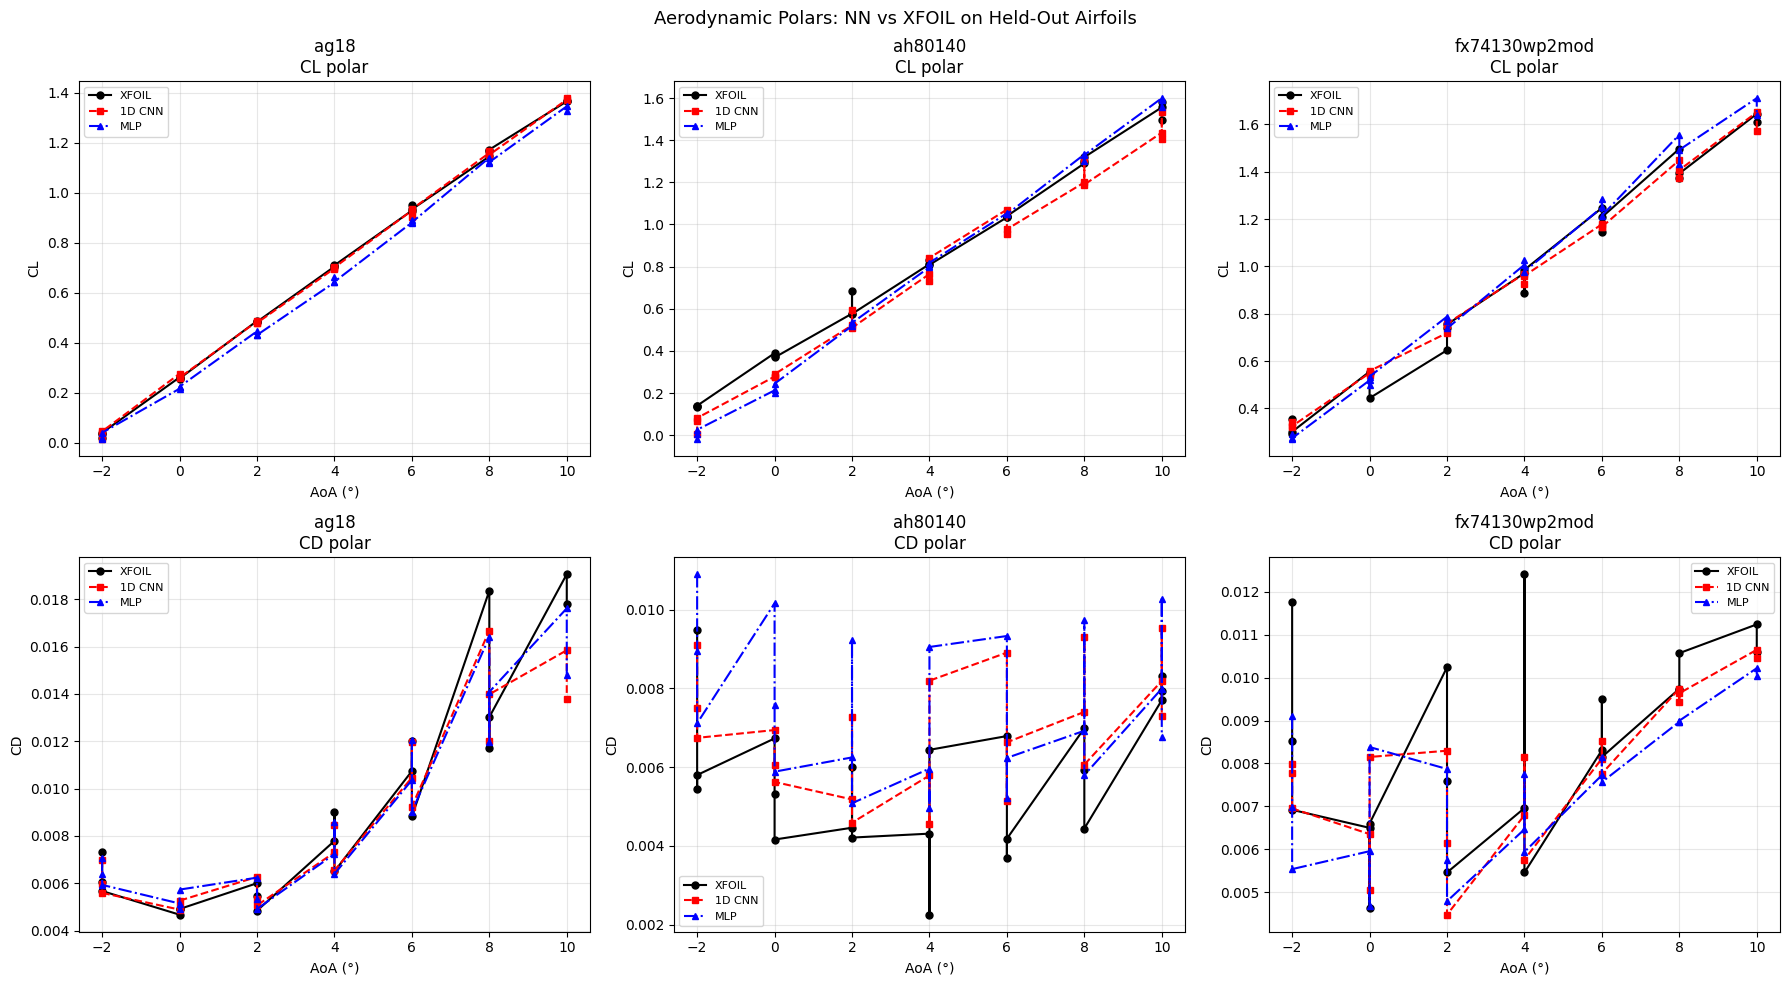

Saved polar_curves.png


In [ ]:
test_foils = df_eval['airfoil_name'].unique()
selected   = np.random.choice(test_foils, size=min(3, len(test_foils)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, foil in enumerate(selected):
    rows = df_eval[df_eval['airfoil_name'] == foil].copy()
    rows = rows.sort_values('aoa').reset_index()
    if len(rows) < 3: continue
    orig_idx = rows['index'].values  # position in df_eval for preds
    for row_ax, (ci, cn) in enumerate([(0,'CL'),(1,'CD')]):
        ax = axes[row_ax, col]
        ax.plot(rows['aoa'], tgt_id[orig_idx, ci], 'k-o',  label='XFOIL', ms=5)
        ax.plot(rows['aoa'], preds_cnn_id[orig_idx, ci], 'r--s', label='1D CNN', ms=5)
        ax.plot(rows['aoa'], preds_mlp_id[orig_idx, ci],'b-.^', label='MLP', ms=5)
        ax.set_xlabel('AoA (°)'); ax.set_ylabel(cn)
        ax.set_title(f'{foil}\n{cn} polar')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Aerodynamic Polars: NN vs XFOIL on Held-Out Airfoils', fontsize=13)
plt.tight_layout()
plt.savefig(_OUTPUT_DIR / 'polar_curves.png', dpi=150)
plt.show()
print('Saved polar_curves.png')

In [ ]:
print('Physical Constraint: CD > 0 (positive drag)')
print('=' * 50)
for label, pred_id, pred_ood in [
    ('MLP',      preds_mlp_id,  preds_mlp_ood),
    ('1D CNN',   preds_cnn_id,  preds_cnn_ood),
    ('CNN+Attn', preds_attn_id, preds_attn_ood),
]:
    n_id = (pred_id[:, 1]  <= 0).sum()
    n_ood = (pred_ood[:, 1] <= 0).sum() if len(pred_ood) > 0 else 0
    pct_id  = n_id  / max(len(pred_id),  1) * 100
    pct_ood = n_ood / max(len(pred_ood), 1) * 100
    print(f'{label:<12} in-dist: {n_id:3d} violations ({pct_id:.2f}%)  '
          f'OOD: {n_ood:3d} ({pct_ood:.2f}%)')

Physical Constraint: CD > 0 (positive drag)
MLP          in-dist:   0 violations (0.00%)  OOD:   0 (0.00%)
1D CNN       in-dist:   0 violations (0.00%)  OOD:   0 (0.00%)
CNN+Attn     in-dist:   0 violations (0.00%)  OOD:   0 (0.00%)


In [ ]:
sample_name  = df_test_id['airfoil_name'].iloc[0]
if _XFOIL_COORD.exists():
    sample_coord = _XFOIL_COORD / f'{sample_name}.dat'
else:
    sample_coord = _COORD_DIR / f'{sample_name}.dat'

print(f'Timing with airfoil: {sample_name}')
print(f'Coord path: {sample_coord}  (exists={sample_coord.exists()})')

# XFOIL timing
xfoil_times = []
for _ in range(10):
    with tempfile.TemporaryDirectory() as tmp:
        inp = (
            f'LOAD {sample_coord}\n{sample_name[:8]}\n'
            'PLOP\nG\n\nPANE\nOPER\n'
            'VISC 1000000\nMACH 0.0\nITER 100\nVPAR\nN 9\n\n'
            'ALFA 5.00\nQUIT\n'
        )
        env = {k: v for k, v in __import__('os').environ.items() if k != 'DISPLAY'}
        t0 = time.perf_counter()
        subprocess.run(['xvfb-run', '-a', 'xfoil'], input=inp,
                       capture_output=True, text=True, timeout=30, env=env)
        xfoil_times.append(time.perf_counter() - t0)

xfoil_ms = np.mean(xfoil_times) * 1000
print(f'XFOIL mean: {xfoil_ms:.1f} ms  (n=10)')

Timing with airfoil: sg6050
Coord path: /content/drive/My Drive/airfoil_surrogate/coordinates/sg6050.dat  (exists=False)
XFOIL mean: 106.4 ms  (n=10)


Improved CNN (single, GPU): 2.050 ms
XFOIL (single, CPU):        106.4 ms
Speedup: 52×


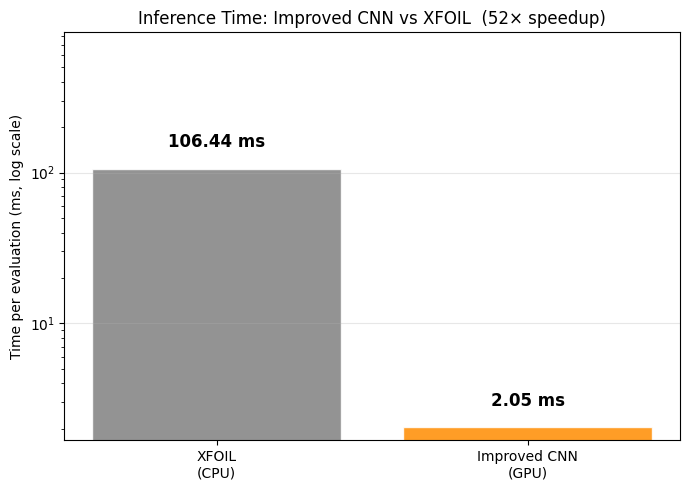

In [ ]:
#timing for improved CNN (geom input: seq + scalar)
g1 = torch.zeros(1, 2, N_GRID).to(DEVICE)
sc1 = torch.zeros(1, SCALAR_DIM).to(DEVICE)

with torch.no_grad():
    for _ in range(50): cnn(g1, sc1)  # warmup
if DEVICE.type == 'cuda': torch.cuda.synchronize()

nn_times = []
with torch.no_grad():
    for _ in range(1000):
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter()
        cnn(g1, sc1)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        nn_times.append(time.perf_counter() - t0)

nn_ms   = np.mean(nn_times) * 1000
speedup = xfoil_ms / nn_ms
print(f'Improved CNN (single, GPU): {nn_ms:.3f} ms')
print(f'XFOIL (single, CPU):        {xfoil_ms:.1f} ms')
print(f'Speedup: {speedup:.0f}×')

with open(_OUTPUT_DIR / 'timing_results.json', 'w') as f:
    json.dump({'xfoil_ms': xfoil_ms, 'nn_ms': nn_ms, 'speedup': speedup}, f, indent=2)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['XFOIL\n(CPU)', 'Improved CNN\n(GPU)'], [xfoil_ms, nn_ms],
              color=['gray', 'darkorange'], alpha=0.85, edgecolor='white')
ax.set_yscale('log')
ax.set_ylabel('Time per evaluation (ms, log scale)')
ax.set_title(f'Inference Time: Improved CNN vs XFOIL  ({speedup:.0f}× speedup)')
for bar, val in zip(bars, [xfoil_ms, nn_ms]):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.3,
            f'{val:.2f} ms', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(top=max(xfoil_ms, nn_ms) * 8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(_OUTPUT_DIR / 'inference_time.png', dpi=150)
plt.show()


In [ ]:
def param_count(m): return sum(p.numel() for p in m.parameters())

rows = []
for model_obj, name, preds, is_geom in [
    (mlp,'MLP Baseline', preds_mlp_id,  False),
    (cnn, 'Improved CNN', preds_cnn_id,  True),
    (cnn_attn, 'CNN + Attn', preds_attn_id, True),
    (None, 'Ensemble (CNN + CNN+Attn)', preds_ens_id,  True),
]:

    if model_obj is not None:
        n_params = param_count(model_obj)
    else:
        n_params = param_count(cnn) + param_count(cnn_attn)

    for ci, cn in [(0,'CL'),(1,'CD')]:
        p, t = preds[:,ci], tgt_id[:,ci]
        if cn == 'CL':
            mape_mask = np.abs(t) > 0.1
        else:
            mape_mask = np.abs(t) > 0.001

        # MAPE calculation
        if mape_mask.sum() > 0:
            mape = np.mean(
                np.abs((p[mape_mask] - t[mape_mask]) / np.abs(t[mape_mask]))) * 100
        else:
            mape = float('nan')
        rows.append({
            'Model':      name,
            'Output':     cn,
            'Params (K)': f'{n_params/1000:.1f}',
            'RMSE':       f'{np.sqrt(np.mean((p-t)**2)):.4f}',
            'MAE':        f'{np.mean(np.abs(p-t)):.4f}',
            'MAPE (%)':   f'{mape:.2f}' if not np.isnan(mape) else 'N/A',
            'R²':         f'{r2_score(t,p):.4f}',
        })

table_df = pd.DataFrame(rows)
print('=== TABLE 1: Test Set Results (In-Distribution, AoA ∈ [-2°, 10°]) ===')
print('Note: MAPE computed on |CL|>0.1, |CD|>0.001 only (avoids near-zero division artefacts)')
print(table_df.to_string(index=False))
table_df.to_csv(_OUTPUT_DIR / 'paper_table1.csv', index=False)

print('\n--- LaTeX ---')
print(table_df.to_latex(
    index=False,
    caption=('Model comparison on held-out test airfoils '
             '(in-distribution, AoA $\\in [-2^\\circ, 10^\\circ]$). '
             'MAPE computed on samples with $|C_L|>0.1$ and $|C_D|>0.001$.'),
    label='tab:results'))

print('\n=== OOD Degradation Summary ===')
ood_rows = []
for name, preds_id, preds_ood, tgt_i, tgt_o in [
    ('MLP', preds_mlp_id, preds_mlp_ood, tgt_id, tgt_ood),
    ('Imp. CNN', preds_cnn_id, preds_cnn_ood, tgt_id, tgt_ood),
]:
    for ci, cn in [(0,'CL'),(1,'CD')]:
        id_r = np.sqrt(np.mean((preds_id[:,ci]  - tgt_i[:,ci])**2))
        ood_r = np.sqrt(np.mean((preds_ood[:,ci] - tgt_o[:,ci])**2))
        ood_rows.append({'Model':name,'Output':cn, 'In-dist RMSE':f'{id_r:.4f}','OOD RMSE':f'{ood_r:.4f}', 'Factor':f'{ood_r/id_r:.1f}×'})
print(pd.DataFrame(ood_rows).to_string(index=False))


=== TABLE 1: Test Set Results (In-Distribution, AoA ∈ [-2°, 10°]) ===
Note: MAPE computed on |CL|>0.1, |CD|>0.001 only (avoids near-zero division artefacts)
                    Model Output Params (K)   RMSE    MAE MAPE (%)     R²
             MLP Baseline     CL      636.3 0.1493 0.0845    13.97 0.9341
             MLP Baseline     CD      636.3 0.0017 0.0012    20.60 0.7401
             Improved CNN     CL     1075.8 0.1143 0.0590     8.81 0.9613
             Improved CNN     CD     1075.8 0.0017 0.0011    21.03 0.7473
               CNN + Attn     CL     1339.5 0.1049 0.0576     8.55 0.9675
               CNN + Attn     CD     1339.5 0.0018 0.0012    22.38 0.7196
Ensemble (CNN + CNN+Attn)     CL     2415.4 0.1064 0.0551     8.12 0.9665
Ensemble (CNN + CNN+Attn)     CD     2415.4 0.0017 0.0011    21.31 0.7417

--- LaTeX ---
\begin{table}
\caption{Model comparison on held-out test airfoils (in-distribution, AoA $\in [-2^\circ, 10^\circ]$). MAPE computed on samples with $|C_L|>0.1$ and

In [ ]:
# Bootstrap confidence intervals for RMSE difference
#used bootstrap resampling to avoid making assumptions about the independence and distribution of my errors. resamples at the observation level not the airfoil level(there are multiple observations per airfoil)
#effective sample size is closer to 45 unique airfoils
import numpy as np
from scipy import stats

np.random.seed(42)
N_BOOTSTRAP = 10000

def bootstrap_rmse_diff(pred_a, pred_b, targets, coeff_idx, n_boot=N_BOOTSTRAP):
    """Bootstrap test: is model A significantly better than model B?
    Returns (mean_diff, ci_low, ci_high, p_value)
    diff = RMSE_B - RMSE_A  (positive = A is better)
    """
    n = len(targets)
    diffs = []
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        t = targets[idx, coeff_idx]
        pa = pred_a[idx, coeff_idx]
        pb = pred_b[idx, coeff_idx]
        rmse_a = np.sqrt(np.mean((pa - t)**2))
        rmse_b = np.sqrt(np.mean((pb - t)**2))
        diffs.append(rmse_b - rmse_a)
    diffs = np.array(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    # p-value: fraction of bootstrap samples where diff <= 0 (A not better)
    p_value = np.mean(diffs <= 0)
    return float(np.mean(diffs)), float(ci_low), float(ci_high), float(p_value)

print('Bootstrap significance tests (10,000 resamples, 95% CI)')
print('Null hypothesis: CNN is not better than MLP')
print('=' * 65)

for coeff_idx, coeff_name in [(0, 'CL'), (1, 'CD')]:
    mean_diff, lo, hi, p = bootstrap_rmse_diff(
        preds_cnn_id, preds_mlp_id, tgt_id, coeff_idx)
    sig = 'significant' if hi > 0 and p < 0.05 else 'not significant'
    print(f'\nCNN vs MLP — {coeff_name}:')
    print(f'  ΔRMSE (MLP−CNN) = {mean_diff:.4f}  95% CI [{lo:.4f}, {hi:.4f}]')
    print(f'  p = {p:.4f}  {sig}')

print()
print('CNN+Attn vs MLP:')
for coeff_idx, coeff_name in [(0, 'CL'), (1, 'CD')]:
    mean_diff, lo, hi, p = bootstrap_rmse_diff(
        preds_attn_id, preds_mlp_id, tgt_id, coeff_idx)
    sig = 'significant' if hi > 0 and p < 0.05 else 'not significant'
    print(f'  {coeff_name}: ΔRMSE = {mean_diff:.4f}  CI [{lo:.4f}, {hi:.4f}]  p={p:.4f}  {sig}')

In [ ]:
# Cluster bootstrap — resamples at the AIRFOIL level, not observation level
# This is the correct approach because observations from the same airfoil are correlated

import numpy as np

np.random.seed(42)
N_BOOTSTRAP = 10000

# We need airfoil names for the test set to define clusters
# These should already be in memory from NB3
# If not: names_test_id = np.load(_p('names_test.npy'))[mask_test]
# Make sure this matches your filtered in-dist test set

def cluster_bootstrap_rmse_diff(pred_a, pred_b, targets, airfoil_names,
                                  coeff_idx, n_boot=N_BOOTSTRAP):
    """
    Cluster bootstrap significance test resampling at the airfoil level.

    Each bootstrap iteration:
      1. Sample N unique airfoils WITH replacement (N = number of unique airfoils)
      2. Take ALL observations belonging to those sampled airfoils
      3. Compute RMSE for both models on that bootstrap sample
      4. Record the difference

    This preserves the correlation structure within airfoils.

    Returns (mean_diff, ci_low, ci_high, p_value)
    diff = RMSE_B - RMSE_A  (positive means A is better)
    """
    unique_foils = np.unique(airfoil_names)
    n_foils = len(unique_foils)
    diffs = []

    for _ in range(n_boot):
        # Sample airfoils with replacement
        sampled_foils = np.random.choice(unique_foils, size=n_foils, replace=True)

        # Collect all observations for those airfoils
        # (a foil sampled twice contributes its observations twice)
        idx = np.concatenate([
            np.where(airfoil_names == foil)[0] for foil in sampled_foils
        ])

        if len(idx) == 0:
            continue

        t = targets[idx, coeff_idx]
        pa = pred_a[idx, coeff_idx]
        pb = pred_b[idx, coeff_idx]

        rmse_a = np.sqrt(np.mean((pa - t)**2))
        rmse_b = np.sqrt(np.mean((pb - t)**2))
        diffs.append(rmse_b - rmse_a)

    diffs = np.array(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p_value = np.mean(diffs <= 0)
    return float(np.mean(diffs)), float(ci_low), float(ci_high), float(p_value)


# Load airfoil names for the in-distribution test set
# names_test.npy contains names for the full raw test set — apply the same mask
names_test_raw = np.load(_p('names_test.npy'), allow_pickle=True)
names_test_id = names_test_raw[mask_test]   # mask_test already defined in NB3

n_unique = len(np.unique(names_test_id))
print(f'Cluster bootstrap — {n_unique} unique airfoils in test set')
print(f'({len(names_test_id)} total observations, {N_BOOTSTRAP} bootstrap iterations)')
print('=' * 65)

print('\nCNN vs MLP (cluster bootstrap):')
for coeff_idx, coeff_name in [(0, 'CL'), (1, 'CD')]:
    mean_diff, lo, hi, p = cluster_bootstrap_rmse_diff(
        preds_cnn_id, preds_mlp_id, tgt_id, names_test_id, coeff_idx)
    sig = 'significant' if lo > 0 and p < 0.05 else 'not significant'
    print(f'  {coeff_name}: ΔRMSE = {mean_diff:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  '
          f'p={p:.4f}  {sig}')

print('\nCNN+Attn vs MLP (cluster bootstrap):')
for coeff_idx, coeff_name in [(0, 'CL'), (1, 'CD')]:
    mean_diff, lo, hi, p = cluster_bootstrap_rmse_diff(
        preds_attn_id, preds_mlp_id, tgt_id, names_test_id, coeff_idx)
    sig = 'significant' if lo > 0 and p < 0.05 else 'not significant'
    print(f'  {coeff_name}: ΔRMSE = {mean_diff:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  '
          f'p={p:.4f}  {sig}')

print('\nEnsemble vs MLP (cluster bootstrap):')
for coeff_idx, coeff_name in [(0, 'CL'), (1, 'CD')]:
    mean_diff, lo, hi, p = cluster_bootstrap_rmse_diff(
        preds_ens_id, preds_mlp_id, tgt_id, names_test_id, coeff_idx)
    sig = 'significant' if lo > 0 and p < 0.05 else 'not significant'
    print(f'  {coeff_name}: ΔRMSE = {mean_diff:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  '
          f'p={p:.4f}  {sig}')

Cluster bootstrap — 45 unique airfoils in test set
(926 total observations, 10000 bootstrap iterations)

CNN vs MLP (cluster bootstrap):
  CL: ΔRMSE = 0.0332  95% CI [-0.0193, 0.1038]  p=0.1937  ❌ not significant
  CD: ΔRMSE = 0.0000  95% CI [-0.0002, 0.0003]  p=0.4219  ❌ not significant

CNN+Attn vs MLP (cluster bootstrap):
  CL: ΔRMSE = 0.0427  95% CI [-0.0078, 0.1130]  p=0.0793  ❌ not significant
  CD: ΔRMSE = -0.0001  95% CI [-0.0003, 0.0002]  p=0.6930  ❌ not significant

Ensemble vs MLP (cluster bootstrap):
  CL: ΔRMSE = 0.0410  95% CI [-0.0101, 0.1124]  p=0.1036  ❌ not significant
  CD: ΔRMSE = 0.0000  95% CI [-0.0002, 0.0003]  p=0.4842  ❌ not significant


In [ ]:
_DRIVE_EVAL = _DRIVE_DIR / 'eval_outputs'
_DRIVE_EVAL.mkdir(parents=True, exist_ok=True)

for fp in sorted(_OUTPUT_DIR.iterdir()):
    shutil.copy(fp, _DRIVE_EVAL / fp.name)
    print(f'  → Drive/eval_outputs/{fp.name}')

print(f'\nAll evaluation outputs saved to {_DRIVE_EVAL}')
print('\nFigures for paper / slides:')
print('  parity_plots.png              → Fig: Predicted vs True (in-dist)')
print('  ood_degradation_by_aoa.png    → Fig: OOD result (key new figure)')
print('  ood_error_vs_distance.png     → Fig: Error grows with OOD distance')
print('  error_breakdown.png           → Fig: Error by AoA and Re')
print('  polar_curves.png              → Fig: Aerodynamic polars')
print('  inference_time.png            → Fig: Speedup vs XFOIL')
print('  paper_table1.csv              → Table 1 (LaTeX printed above)')

  → Drive/eval_outputs/error_breakdown.png
  → Drive/eval_outputs/inference_time.png
  → Drive/eval_outputs/ood_degradation_by_aoa.png
  → Drive/eval_outputs/ood_error_vs_distance.png
  → Drive/eval_outputs/paper_table1.csv
  → Drive/eval_outputs/parity_plots.png
  → Drive/eval_outputs/polar_curves.png
  → Drive/eval_outputs/timing_results.json

All evaluation outputs saved to /content/drive/My Drive/airfoil_surrogate/eval_outputs

Figures for paper / slides:
  parity_plots.png              → Fig: Predicted vs True (in-dist)
  ood_degradation_by_aoa.png    → Fig: OOD result (key new figure)
  ood_error_vs_distance.png     → Fig: Error grows with OOD distance
  error_breakdown.png           → Fig: Error by AoA and Re
  polar_curves.png              → Fig: Aerodynamic polars
  inference_time.png            → Fig: Speedup vs XFOIL
  paper_table1.csv              → Table 1 (LaTeX printed above)


In [ ]:
import shutil
shutil.make_archive("eval_outputs", 'zip', "eval_outputs")

from google.colab import files
files.download("eval_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>